# softmax回归的简洁实现
---
## 环境配置


In [ ]:
%pip install pypto==0.2.0 torch torch_npu numpy

In [ ]:
import os, sys
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import pypto
import torch
import torch_npu
import numpy as np
import torchvision
from torch.utils import data
from torchvision import transforms

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
mode = pypto.RunMode.NPU

---

## 练习3.7.1

尝试调整超参数，例如批量大小、迭代周期数和学习率，并查看结果。


### 解答


以下使用 `torch` 编程进行验证：


In [3]:
import torch
from torch import nn
import torchvision
from torch.utils import data
from torchvision import transforms
from IPython import display
import matplotlib.pyplot as plt

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=0),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=0))

class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    def reset(self):
        self.data = [0.0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter):
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

def train_epoch_ch3(net, train_iter, loss, updater):
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]

class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

CPU times: user 1min 59s, sys: 3.83 s, total: 2min 3s
Wall time: 1min 1s


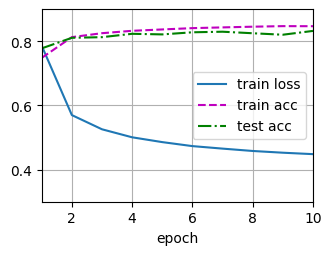

In [4]:
%%time
num_epochs = 10
batch_size = 256

train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

CPU times: user 19min 52s, sys: 35.4 s, total: 20min 27s
Wall time: 10min 19s


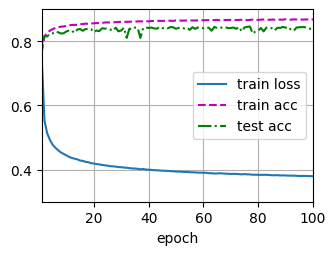

In [5]:
%%time
net.apply(init_weights)
num_epochs = 100
batch_size = 256

train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

CPU times: user 14min 19s, sys: 53 s, total: 15min 12s
Wall time: 1min 51s


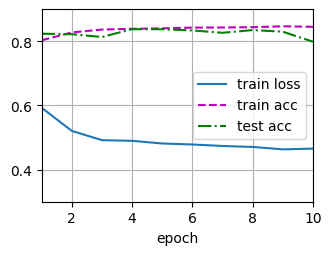

In [6]:
%%time
net.apply(init_weights)
num_epochs = 10
batch_size = 16

train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

CPU times: user 4min 22s, sys: 15 s, total: 4min 37s
Wall time: 1min 12s


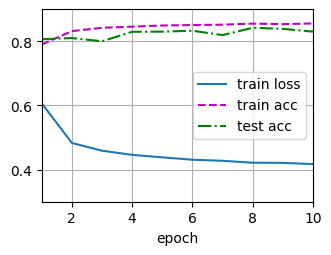

In [7]:
%%time
net.apply(init_weights)
num_epochs = 10
batch_size = 64

train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

CPU times: user 2min 55s, sys: 6.88 s, total: 3min 2s
Wall time: 1min 5s


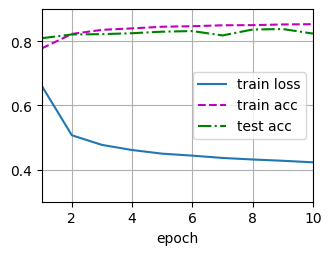

In [8]:
%%time
net.apply(init_weights)
num_epochs = 10
batch_size = 128

train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

CPU times: user 3min 5s, sys: 1.17 s, total: 3min 6s
Wall time: 1min 59s


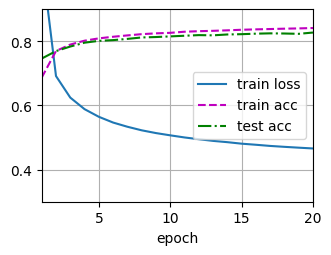

In [9]:
%%time
net.apply(init_weights)
num_epochs = 20
batch_size = 1024

train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

CPU times: user 5min 55s, sys: 12.1 s, total: 6min 7s
Wall time: 2min 11s


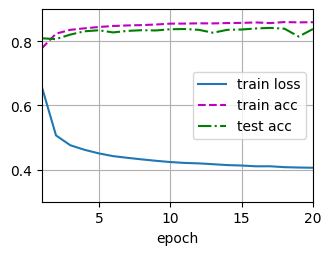

In [10]:
%%time
net.apply(init_weights)
num_epochs = 20
batch_size = 128

train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

CPU times: user 1min 58s, sys: 3.41 s, total: 2min 2s
Wall time: 1min 2s


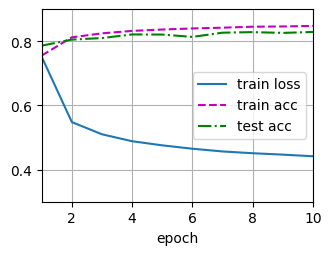

In [11]:
%%time
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

net.apply(init_weights)
num_epochs = 10
batch_size = 256

train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

1.4328932034810384
CPU times: user 2min, sys: 3.05 s, total: 2min 3s
Wall time: 1min 1s


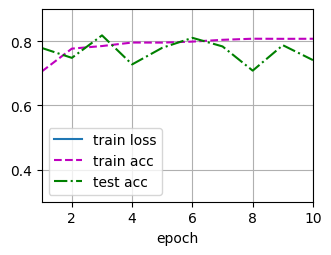

In [12]:
%%time
try:
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=1)

    net.apply(init_weights)
    num_epochs = 10
    batch_size = 256

    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
except Exception as e:
    print(e)

1.2124218285878499
CPU times: user 19min 48s, sys: 36.3 s, total: 20min 24s
Wall time: 10min 20s


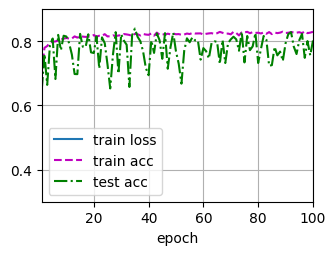

In [13]:
%%time
try:
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=1)

    net.apply(init_weights)
    num_epochs = 100
    batch_size = 256

    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
except Exception as e:
    print(e)

0.6361528659820557
CPU times: user 1min 58s, sys: 3.96 s, total: 2min 2s
Wall time: 1min 1s


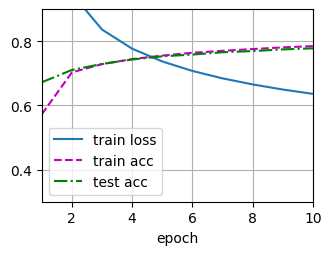

In [14]:
%%time
try:
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)

    net.apply(init_weights)
    num_epochs = 10
    batch_size = 256

    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
except Exception as e:
    print(e)

1.0517736251831056
CPU times: user 1min 58s, sys: 3.37 s, total: 2min 2s
Wall time: 1min 1s


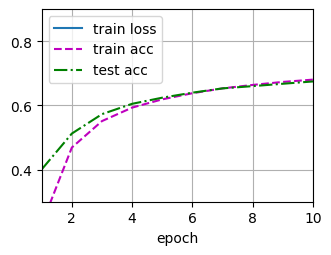

In [15]:
%%time
try:
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=0.001)

    net.apply(init_weights)
    num_epochs = 10
    batch_size = 256

    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
except Exception as e:
    print(e)

0.6215733938852946
CPU times: user 19min 46s, sys: 36.7 s, total: 20min 23s
Wall time: 10min 18s


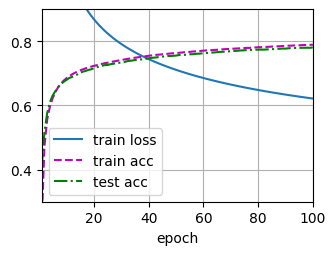

In [16]:
%%time
try:
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=0.001)

    net.apply(init_weights)
    num_epochs = 100
    batch_size = 256

    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
except Exception as e:
    print(e)

2.314808852895101
CPU times: user 1min 59s, sys: 3.67 s, total: 2min 3s
Wall time: 1min 2s


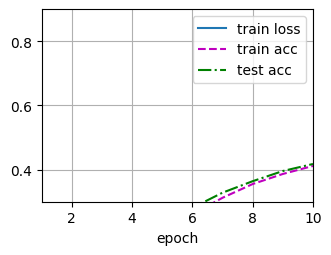

In [17]:
%%time
try:
    loss = nn.CrossEntropyLoss(reduction='none')
    trainer = torch.optim.SGD(net.parameters(), lr=0.0001)

    net.apply(init_weights)
    num_epochs = 10
    batch_size = 256

    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
except Exception as e:
    print(e)

使用 `PyPTO` 编程进行验证:


我们在 PyPTO 上复现 softmax 回归的简洁实现：用 PyPTO 算子实现 `linear`、`softmax`、`cross_entropy`、`accuracy` 的前向与反向，并借助 `torch.autograd.Function` 接入 PyTorch 的 autograd 框架。然后调整批量大小、迭代周期数和学习率等超参数，观察训练效果。


线性层：前向 / 反向 PyPTO 算子。


In [18]:
@pypto.frontend.jit
def linear_forward_kernel(
    X: pypto.Tensor([], pypto.DT_FP32),
    W: pypto.Tensor([], pypto.DT_FP32),
    b_2d: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([32, 32], [64, 64], [64, 64])
    out[:] = pypto.matmul(X, W, pypto.DT_FP32,
                          extend_params={'bias_tensor': b_2d})

@pypto.frontend.jit()
def linear_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    X: pypto.Tensor([], pypto.DT_FP32),
    W: pypto.Tensor([], pypto.DT_FP32),
    grad_X: pypto.Tensor([], pypto.DT_FP32),
    grad_W: pypto.Tensor([], pypto.DT_FP32),
    grad_b_2d: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([32, 32], [64, 64], [64, 64])
    grad_X[:] = pypto.matmul(grad_out, W, pypto.DT_FP32, b_trans=True)
    grad_W[:] = pypto.matmul(X, grad_out, pypto.DT_FP32, a_trans=True)
    pypto.set_vec_tile_shapes(16, 16)
    grad_b_2d[:] = pypto.sum(grad_out, dim=0, keepdim=True)

class PyPTOLinearFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, X, W, b):
        X_c, W_c = X.contiguous(), W.contiguous()
        b_2d = b.contiguous().view(1, -1)
        out = torch.empty((X.shape[0], W.shape[1]), dtype=X.dtype, device=X.device)
        linear_forward_kernel(X_c, W_c, b_2d, out)
        ctx.save_for_backward(X_c, W_c)
        return out

    @staticmethod
    def backward(ctx, grad_out):
        X, W = ctx.saved_tensors
        grad_out_c = grad_out.contiguous()
        grad_X = torch.empty_like(X)
        grad_W = torch.empty_like(W)
        grad_b_2d = torch.empty((1, W.shape[1]), dtype=W.dtype, device=W.device)
        linear_backward_kernel(grad_out_c, X, W, grad_X, grad_W, grad_b_2d)
        grad_b = grad_b_2d.view(-1)
        return grad_X, grad_W, grad_b

softmax：前向 / 反向 PyPTO 算子。


In [19]:
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def softmax_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(16, 16)
    out[:] = pypto.softmax(x, dim=-1)

@pypto.frontend.jit()
def softmax_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_x: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(16, 16)
    grad_x[:] = y * (grad_out - pypto.sum(grad_out * y, dim=-1, keepdim=True))

class PyPTOSoftmaxFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        x_c = x.contiguous()
        out = torch.empty_like(x_c)
        softmax_kernel(x_c, out)
        ctx.save_for_backward(out)
        return out

    @staticmethod
    def backward(ctx, grad_out):
        (y,) = ctx.saved_tensors
        grad_x = torch.empty_like(y)
        softmax_backward_kernel(grad_out.contiguous(), y, grad_x)
        return grad_x

交叉熵损失：前向 / 反向 PyPTO 算子。


In [20]:
@pypto.frontend.jit()
def cross_entropy_forward_kernel(
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y_1d: pypto.Tensor([], pypto.DT_INT32),
    out: pypto.Tensor([], pypto.DT_FP32),
    num_classes: int,
):
    y_2d = pypto.reshape(y_1d, [-1, 1])
    pypto.set_vec_tile_shapes(8, ((num_classes + 7) // 8) * 8)
    selected = pypto.gather(y_hat, -1, y_2d)
    out[:] = pypto.neg(pypto.log(pypto.maximum(selected, 1e-12)))

@pypto.frontend.jit()
def cross_entropy_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y_1d: pypto.Tensor([], pypto.DT_INT32),
    grad_y_hat: pypto.Tensor([], pypto.DT_FP32),
    num_classes: int,
):
    y_2d = pypto.reshape(y_1d, [-1, 1])
    pypto.set_vec_tile_shapes(8, ((num_classes + 7) // 8) * 8)
    selected = pypto.gather(y_hat, -1, y_2d)
    selected_safe = pypto.maximum(selected, 1e-12)
    pypto.set_vec_tile_shapes(8, num_classes)
    one_hot_y = pypto.cast(pypto.one_hot(y_1d, num_classes), pypto.DT_FP32)
    pypto.set_vec_tile_shapes(8, 8)
    grad_y_hat[:] = -(grad_out / selected_safe) * one_hot_y

class PyPTOCrossEntropyFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, y_hat, y, num_classes):
        y_hat_c = y_hat.contiguous()
        y_i32_1d = y.to(torch.int32).contiguous()
        out = torch.empty((y_hat.shape[0], 1), dtype=y_hat.dtype, device=y_hat.device)
        cross_entropy_forward_kernel(y_hat_c, y_i32_1d, out, num_classes)
        ctx.save_for_backward(y_hat, y_i32_1d)
        ctx.num_classes = num_classes
        return out.view(-1)

    @staticmethod
    def backward(ctx, grad_out):
        y_hat, y_i32_1d = ctx.saved_tensors
        grad_out_c = grad_out.view(-1, 1).contiguous()
        grad_y_hat = torch.empty_like(y_hat)
        cross_entropy_backward_kernel(
            grad_out_c, y_hat, y_i32_1d, grad_y_hat, ctx.num_classes
        )
        return grad_y_hat, None, None

def cross_entropy(y_hat, y):
    return PyPTOCrossEntropyFunction.apply(y_hat, y, y_hat.shape[1])

分类精度：PyPTO 算子。


In [21]:
@pypto.frontend.jit()
def accuracy_kernel(
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_INT64),
    correct: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(16, 16)
    res = pypto.topk(y_hat, 1, -1, True)
    argmax_i32 = res[1]

    argmax_f32 = pypto.cast(argmax_i32, pypto.DT_FP32)
    y_f32 = pypto.cast(pypto.reshape(y, [-1, 1]), pypto.DT_FP32)
    cmp = pypto.eq(argmax_f32, y_f32)
    cmp_num = pypto.where(cmp, 1.0, 0.0)

    total = pypto.sum(cmp_num, dim=0, keepdim=False)
    correct[:] = total

def accuracy(y_hat, y):
    correct = torch.empty((1,), dtype=torch.float32, device=y_hat.device)
    accuracy_kernel(y_hat.contiguous(), y.contiguous(), correct)
    return float(correct.item())

接下来定义 Fashion-MNIST 数据加载、模型和训练辅助函数。


In [22]:
def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=0),
            data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=0))

num_inputs = 784
num_outputs = 10

def init_params():
    W = torch.normal(0, 0.01, size=(num_inputs, num_outputs),
                     device='npu:0', requires_grad=True)
    b = torch.zeros(num_outputs, device='npu:0', requires_grad=True)
    return W, b

def net(X, W, b):
    return PyPTOSoftmaxFunction.apply(
        PyPTOLinearFunction.apply(X.reshape((-1, W.shape[0])), W, b)
    )

def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

训练辅助函数：与原文相比，去掉了基于 matplotlib 的 `Animator`，直接打印每轮的损失和精度。


In [23]:
def evaluate_accuracy(W, b, data_iter):
    n_correct, n_total = 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.npu()
            y = y.npu()
            n_correct += accuracy(net(X, W, b), y)
            n_total += y.numel()
    return n_correct / n_total

def train_epoch_ch3(W, b, train_iter, lr):
    loss_sum, acc_sum, n = 0.0, 0.0, 0
    for X, y in train_iter:
        X = X.npu()
        y = y.npu()
        y_hat = net(X, W, b)
        l = cross_entropy(y_hat, y)
        l.sum().backward()
        sgd([W, b], lr, X.shape[0])
        loss_sum += float(l.sum())
        acc_sum += accuracy(y_hat, y)
        n += y.numel()
    return loss_sum / n, acc_sum / n

def train_ch3(W, b, train_iter, test_iter, num_epochs, lr):
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch_ch3(W, b, train_iter, lr)
        test_acc = evaluate_accuracy(W, b, test_iter)
        print(f'epoch {epoch + 1}, train loss {train_loss:.4f}, '
              f'train acc {train_acc:.4f}, test acc {test_acc:.4f}')

基线实验：`batch_size=256`、`num_epochs=5`、`lr=0.1`。


In [24]:
batch_size = 256
num_epochs = 5
lr = 0.1

train_iter, test_iter = load_data_fashion_mnist(batch_size)
W, b = init_params()
train_ch3(W, b, train_iter, test_iter, num_epochs, lr)

epoch 1, train loss 0.7864, train acc 0.7467, test acc 0.7917
epoch 2, train loss 0.5707, train acc 0.8126, test acc 0.8084
epoch 3, train loss 0.5249, train acc 0.8258, test acc 0.8150
epoch 4, train loss 0.5004, train acc 0.8319, test acc 0.8239
epoch 5, train loss 0.4853, train acc 0.8367, test acc 0.8243


减小批量大小：`batch_size=64`。


In [25]:
batch_size = 64
num_epochs = 5
lr = 0.1

train_iter, test_iter = load_data_fashion_mnist(batch_size)
W, b = init_params()
train_ch3(W, b, train_iter, test_iter, num_epochs, lr)

epoch 1, train loss 0.6208, train acc 0.7899, test acc 0.8157
epoch 2, train loss 0.4914, train acc 0.8310, test acc 0.8246
epoch 3, train loss 0.4646, train acc 0.8405, test acc 0.8343
epoch 4, train loss 0.4496, train acc 0.8462, test acc 0.8157
epoch 5, train loss 0.4414, train acc 0.8481, test acc 0.8346


增大批量大小：`batch_size=1024`。


In [26]:
batch_size = 1024
num_epochs = 5
lr = 0.1

train_iter, test_iter = load_data_fashion_mnist(batch_size)
W, b = init_params()
train_ch3(W, b, train_iter, test_iter, num_epochs, lr)

epoch 1, train loss 1.0921, train acc 0.6688, test acc 0.7347
epoch 2, train loss 0.7378, train acc 0.7676, test acc 0.7670
epoch 3, train loss 0.6602, train acc 0.7912, test acc 0.7847
epoch 4, train loss 0.6182, train acc 0.8026, test acc 0.7939
epoch 5, train loss 0.5899, train acc 0.8103, test acc 0.8027


增大学习率：`lr=1.0`，过大的学习率可能导致训练发散。


In [27]:
batch_size = 256
num_epochs = 5
lr = 1.0

train_iter, test_iter = load_data_fashion_mnist(batch_size)
W, b = init_params()
try:
    train_ch3(W, b, train_iter, test_iter, num_epochs, lr)
except Exception as e:
    print(e)

epoch 1, train loss 4.6866, train acc 0.6791, test acc 0.7099
epoch 2, train loss 3.7050, train acc 0.7353, test acc 0.6057
epoch 3, train loss 1.9117, train acc 0.7756, test acc 0.7844
epoch 4, train loss 1.5730, train acc 0.7944, test acc 0.7514
epoch 5, train loss 1.5575, train acc 0.7971, test acc 0.8186


减小学习率：`lr=0.01`，过小的学习率会导致收敛过慢。


In [28]:
batch_size = 256
num_epochs = 5
lr = 0.01

train_iter, test_iter = load_data_fashion_mnist(batch_size)
W, b = init_params()
train_ch3(W, b, train_iter, test_iter, num_epochs, lr)

epoch 1, train loss 1.3704, train acc 0.6377, test acc 0.6839
epoch 2, train loss 0.9179, train acc 0.7162, test acc 0.7224
epoch 3, train loss 0.8036, train acc 0.7496, test acc 0.7465
epoch 4, train loss 0.7431, train acc 0.7673, test acc 0.7608
epoch 5, train loss 0.7033, train acc 0.7797, test acc 0.7693


增加迭代周期数：`num_epochs=20`。


In [29]:
batch_size = 256
num_epochs = 20
lr = 0.1

train_iter, test_iter = load_data_fashion_mnist(batch_size)
W, b = init_params()
train_ch3(W, b, train_iter, test_iter, num_epochs, lr)

epoch 1, train loss 0.7885, train acc 0.7461, test acc 0.7903
epoch 2, train loss 0.5699, train acc 0.8128, test acc 0.8142
epoch 3, train loss 0.5246, train acc 0.8264, test acc 0.8131
epoch 4, train loss 0.5001, train acc 0.8326, test acc 0.8185
epoch 5, train loss 0.4867, train acc 0.8379, test acc 0.8243
epoch 6, train loss 0.4738, train acc 0.8399, test acc 0.8263
epoch 7, train loss 0.4650, train acc 0.8428, test acc 0.8194
epoch 8, train loss 0.4576, train acc 0.8455, test acc 0.8233
epoch 9, train loss 0.4526, train acc 0.8468, test acc 0.8294
epoch 10, train loss 0.4471, train acc 0.8486, test acc 0.8277
epoch 11, train loss 0.4434, train acc 0.8495, test acc 0.8247
epoch 12, train loss 0.4384, train acc 0.8508, test acc 0.8353
epoch 13, train loss 0.4360, train acc 0.8526, test acc 0.8371
epoch 14, train loss 0.4331, train acc 0.8520, test acc 0.8388
epoch 15, train loss 0.4305, train acc 0.8537, test acc 0.8207
epoch 16, train loss 0.4278, train acc 0.8535, test acc 0.8273
e

通过实验，我们发现：
1. 学习率越小，收敛越慢，同时可能存在局部收敛的问题，影响训练精度。
2. 轮数越多，一般效果越好，但可能因为训练精度已收敛，会花费不必要的训练时间。
3. `batch_size`越大，训练时间越短，但是可能会影响训练精度，并且`batch_size`与机器相关，使用`GPU`训练时，显存较小可能无法满足大`batch_size`训练。


---


## 练习3.7.2

增加轮数，为什么测试精度会在一段时间后降低？我们怎么解决这个问题？


### 解答


增加迭代周期的数量可能会导致过拟合，从而导致测试精度下降。具体来说，当我们增加迭代周期的数量时，模型可能会开始学习到一些只能满足训练样本的非共性特征（这些更多是一种偶然性特征，不适用于测试样本），从而导致过拟合。为了解决这个问题，可以使用早停技术或正则化技术。早停技术是指在模型出现过拟合时（测试集表现开始下降）停止训练。正则化技术是指通过向损失函数添加惩罚项来限制模型参数的大小，从而减少过拟合。


---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
